In [108]:
import serial
from ReadWrite import ReadWrite
import pandas as pd
from matplotlib import pyplot as plt
from Network import RKMNetwork
from func_timeout import func_timeout, FunctionTimedOut
import time
import ast
import numpy as np
from datetime import datetime
import matplotlib as mpl
import scipy
import json
# print(scipy.__version__)
# from scipy.interpolate import make_smoothing_spline

# from scipy.interpolate import UnivariateSpline as make_smoothing_spline

import os
lam = 20
import random

In [150]:
port = "/dev/ttyACM1" # Replace with your serial port
baudrate = 250000
ser = serial.Serial(port, baudrate)
ser.is_open

True


  name  isWeight Anode Bnode
0  BV0         0    A0    V0
1  BH0         0    A0    H0
2  W00         1    V0    H0


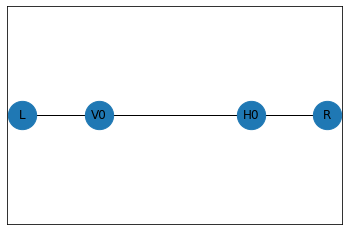

In [151]:
numV = 1
numH = 1

net = RKMNetwork(numV,numH)

net.draw_network()

print(net.edge)
# print(net.node)

In [152]:
def cleanup_mes(thisdict): 
    ki = thisdict['ki']
    DA = thisdict['DA']
    DB = thisdict['DB']
    RA = thisdict['RA']
    RB = thisdict['RB']
    
    if not (net.run_nodechecks(DA, DB) and net.run_nodechecks(RA, RB)):
        print("failed nodecheck")
        return None
    
    edges = dict(zip(net.edge.name, ki))
    
    Dnodes = dict(zip(net.edge.Anode, DA))
    Dnodes.update(dict(zip(net.edge.Bnode, DB)))
    
    Rnodes = dict(zip(net.edge.Anode, RA))
    Rnodes.update(dict(zip(net.edge.Bnode, RB)))

    
    newdict = {}
    newdict.update(edges)
    
    for key in Dnodes:
        newdict['D' + key] = Dnodes[key]
    
    for key in Rnodes:
        newdict['R' + key] = Rnodes[key]
        
    return newdict

In [153]:
aConvert = (3.3)/(4095.)
def cleanup_dict(thisdict): 
    aConvert = (3.3)/(4095.)
    ki = thisdict['ki']
    DA = thisdict['DA']
    DB = thisdict['DB']
    RA = thisdict['RA']
    RB = thisdict['RB']
    
    nmestimes = 5. #thisdict['nmestimes']
    aConvert = aConvert*1/nmestimes
    
    if not (net.run_nodechecks(DA, DB) and net.run_nodechecks(RA, RB)):
        print("failed nodecheck")
        return None
    
    edges = dict(zip(net.edge.name, ki))
    
    Dnodes = dict(zip(net.edge.Anode, DA))
    Dnodes.update(dict(zip(net.edge.Bnode, DB)))
    
    Rnodes = dict(zip(net.edge.Anode, RA))
    Rnodes.update(dict(zip(net.edge.Bnode, RB)))

    
    newdict = {'epoch': thisdict['epoch'],  'trainingstep': thisdict['epoch'], 
               'Vtest': thisdict['Vtest'], 'Vrecon': thisdict['Vrecon']}
    newdict.update(edges)
    
    try:
        newdict['Vtest_det'] = thisdict['Vtest_det']
        newdict['Vrecon_det'] = thisdict['Vrecon_det']
    except:
        pass
    
    for key in Dnodes:
        newdict['D' + key] = Dnodes[key]
    
    for key in Rnodes:
        newdict['R' + key] = Rnodes[key]

    try:
        azero = np.array(thisdict['analogZero'], dtype='float')*aConvert
        newdict['analogZero'] = azero
        
        analogV = thisdict['analogV']
        analogH = thisdict['analogH']
        for i, val in enumerate(analogV):
            newdict['aV' + str(i)] = val*aConvert
        
        for i, val in enumerate(analogH):
            newdict['aH' + str(i)] = val*aConvert
    except Exception as e: 
        print('Epoch', newdict['epoch'])
        print(e)
        
    return newdict

In [154]:
RW = ReadWrite(ser)

In [155]:
# get experiment info and setup random seeds

def set_seeds(RW=RW):
    
    RW.clear_output()
    RW.send_message("ps;")
    time.sleep(1)
    experiment_data = RW.measure()

    ebAddress = experiment_data['ebAddress']

    seeds = np.random.randint(0, 100, len(ebAddress))

    while len(seeds) > len(set(seeds)):
        for i in range(len(seeds)):
            seeds[i] = random.randint(0, 100)

    for i in range(len(ebAddress)):
        RW.send_recieve("seed;{};{};".format(ebAddress[i], seeds[i]))
        time.sleep(1)
        
set_seeds()

sending edge type and index
W, 2
ebAddress, [1]
temp0, 0
detinf, 1
board, 1
seed, 31


In [158]:
hyperparams = {'digitemp': 20, # temperature (in digipot clicks - change to amplitude)
               'L2': 7, 'L2maxexp': 4, #L2 term (split into two values - change eventually)
               'alpha': 1, # learning rate (in digipot clicks)
               'epochs': 100, # number of training steps (show all data points)
               'measureEvery': 10, # how many epochs to skip between measurements (measureEvery = 1 : measure all epochs)
               'kwvar': 30, 'kbvar': 5, # edge initialization
               'detInf': 1, # deterministic inference on (1) or off (0)
               'ensembleName': 'newtest', # folder header
               'includeInName': [] #hyperparameters to include in folder
              }

In [159]:
# set hyperparameters for training

def set_hyperparams(hyperparams, RW=RW, date=None):

    ensemblename = hyperparams['ensembleName'] #save folder
    for val in hyperparams['includeInName']:
        ensemblename += '_' + val + '_' + str(hyperparams[val])

    if not date:
        date = datetime.today().strftime('%m%d%Y')
    ensemblename += '_' + date
    
    folderpath = 'data/trainings/{}/'.format(ensemblename)

    if not os.path.exists(folderpath):
            os.mkdir(folderpath)
            
    with open(folderpath + "hyperparams.json", "w") as f:
        json.dump(hyperparams, f)

    RW.send_recieve("alpha;{};".format(hyperparams['alpha']))
    time.sleep(1)
    RW.send_recieve("kwvar;{};".format(hyperparams['kwvar']))
    time.sleep(1)
    RW.send_recieve("kbvar;{};".format(hyperparams['kbvar']))
    time.sleep(1)
    RW.send_recieve("L2;{};".format(hyperparams['L2']))
    time.sleep(1)
    RW.send_recieve("L2max;{};".format(hyperparams['L2maxexp']))
    time.sleep(1)
    RW.send_recieve("measureEvery;{};".format(hyperparams['measureEvery']))
    time.sleep(1)

    if hyperparams['digitemp'] == -1:
        RW.send_recieve("zeroTtrain;")
        time.sleep(1)
    else:
        RW.send_recieve("finiteTtrain;")
        time.sleep(1)
        RW.send_recieve("setvtemp;{};".format(hyperparams['digitemp']))
        time.sleep(1)
        RW.send_recieve("sethtemp;{};".format(hyperparams['digitemp']))
        time.sleep(1)
        RW.send_recieve("detinf;{};".format(hyperparams['detInf']))
        time.sleep(1)


    # check edge initialization works according to hyperparams
    RW.clear_output()
    RW.send_recieve("rd;")
    RW.send_recieve("rr;")
    time.sleep(1)
    RW.send_recieve("norm;")
    time.sleep(1)
    RW.clear_output()
    RW.send_message("mes;")
    mes = RW.measure()
    out = cleanup_mes(mes)
    allGood = True
    if out:
        for x in [x for x in out.keys() if x[:2] == 'BV']:
            if out[x] != hyperparams['kbvar']:
                allGood = False
                print("visible bias not initialized correctly")
        for x in [x for x in out.keys() if x[:2] == 'BH']:
            if out[x] != 0:
                allGood = False
                print("hidden bias not initialized correctly")
        for x in [x for x in out.keys() if x[0] == 'W']:
            if np.abs(out[x]) > hyperparams['kwvar'] :
                allGood = False
                print("weight not initialized correctly")
        for x in [x for x in out.keys if x[0]== 'D' or x[0]=='R']:
            if out[x] > 1 or out[x] < 0:
                allGood = False
                print("digitized node values are not 0/1")
    else:
        allGood = False
        
    if allGood:
        print("all checks passed")
        
    return folderpath

folderpath = set_hyperparams(hyperparams)

alpha, 1
kwvar, 30
kbvar, 5
L2, 7
L2max, 4
measureEvery, 10
temp0, 0
set Vtemp, 20
set Htemp, 20
detInf, 1
recordD triggered
recordR triggered
normed
ki, [5, 0, 21]
DA, [1, 1, 1]
DB, [1, 0, 0]
RA, [1, 1, 1]
RB, [1, 0, 0]
all checks passed


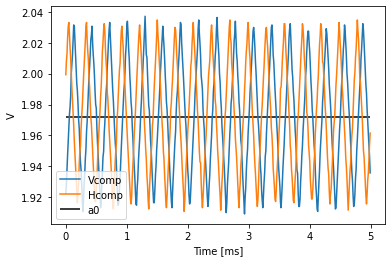

In [160]:
# check temperature signals

def plot_temp(RW=RW, nmes=500, sample_delay=10):
    RW.clear_output()
    time.sleep(1)
    RW.send_message("ames;0;")
    time.sleep(1)
    out = RW.measure(suppress=True)

    a0 = float(out['analogZero'])/int(out['nmestimes'])*aConvert

    tmes = np.arange(nmes)*sample_delay*1e-3
    
    plt.hlines(a0, 0, np.max(tmes), color='k', label='a0')
    
    time.sleep(1)
    RW.send_message("sampletemp;{};{};{};".format(nmes, sample_delay, 0))
    out = RW.measure(suppress=True)

    tempSig = [x*aConvert for x in out['analogTemp']]

    plt.plot(tmes, tempSig, label='Vcomp')

    RW.send_message("sampletemp;{};{};{};".format(nmes, sample_delay, 1))
    out = RW.measure(suppress=True)

    tempSig = [x*aConvert for x in out['analogTemp']]

    plt.plot(tmes, tempSig, label='Hcomp')
    plt.legend()
    plt.xlabel('Time [ms]')
    plt.ylabel('V')
    plt.show()
    
    return tempSig

tempSig = plot_temp()

In [161]:
# train

def train(hyperparams, RW=RW, folderpath=folderpath, trialnum=0):
    print('Beginning Trial {}'.format(trialnum))
    RW.clear_output()
    time.sleep(1)

    # set initial values
    RW.send_recieve("fb;0;", suppress=True)
    time.sleep(1)
    RW.send_recieve("useprev;0;", suppress=True)
    time.sleep(1)
    RW.send_recieve("clamp;0;", suppress=True)
    time.sleep(1)
    RW.send_recieve("reset;", suppress=True)
    time.sleep(1)
    RW.send_recieve("norm;", suppress=True)
    RW.clear_output()
    time.sleep(1)
    RW.send_message("mes;")
    eki = RW.measure()['ki']

    first = dict(zip(net.edge.name, eki))
    first['epoch'] = -1
    first['trainingstep'] = -1


    RW.clear_output()
    time.sleep(1)
    RW.send_message("train;{};".format(hyperparams['epochs']))
    listodicts = RW.train_measure(timeoutval=1e4)


    listodicts[0].update(first)
    try:
        del listodicts[0]['finalizereconstruct']
        del listodicts[0]['testidx']
    except:
        print(listodicts[0].keys())

    for i in range(1, len(listodicts)):
        listodicts[i] = cleanup_dict(listodicts[i])

    df = pd.DataFrame(listodicts)
    # # hyperparams
    df['L2'] = float(hyperparams['L2'])/10**hyperparams['L2maxexp']
    df['alpha'] = hyperparams['alpha']
    df['kwvar'] = hyperparams['kwvar']
    df['kbvar'] = hyperparams['kbvar']
    df['digitemp'] = hyperparams['digitemp']

    df.epoch = pd.to_numeric(df.epoch)
    df.trainingstep = pd.to_numeric(df.trainingstep)
    df['folderpath'] = folderpath
    df['trialNum'] = trialnum

    MSEs = []
    MSEs_det = []
    for epoch in df.epoch:
        row = df[df.epoch == epoch].iloc[0]


        Vtest = np.array(row.Vtest).T
        Vrecon = np.array(row.Vrecon).T
        MSE = np.mean(np.linalg.norm(Vtest-Vrecon, axis=0))
        MSEs.append(MSE)

        try:
            Vtest_det = np.array(row.Vtest_det).T
            Vrecon_det = np.array(row.Vrecon_det).T
            MSEdet = np.mean(np.linalg.norm(Vtest_det-Vrecon_det, axis=0))
            MSEs_det.append(MSEdet)
        except:
            pass


    MSEs = np.array(MSEs)
    MSEs_det = np.array(MSEs_det)
    df['MSE'] = MSEs

    if len(MSEs_det) > 0:
        df['MSE_det'] = MSEs_det
    print('Done with training')
    
    df.to_csv(folderpath + 'trial{}.csv'.format(str(trialnum).zfill(2)))
    return df


df = train(hyperparams, folderpath=folderpath, trialnum=0)

Beginning Trial 0
ki, [5, 0, 12]
DA, [1, 1, 1]
DB, [1, 0, 0]
RA, [1, 1, 1]
RB, [1, 0, 0]
Done with training


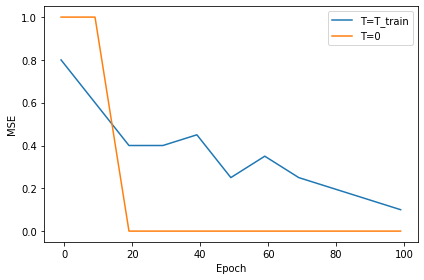

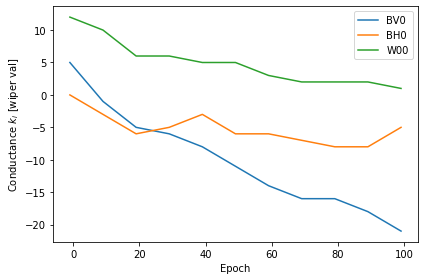

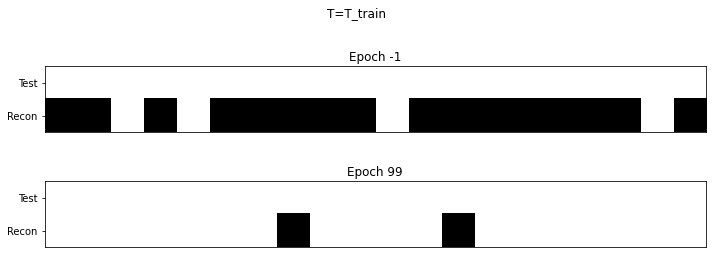

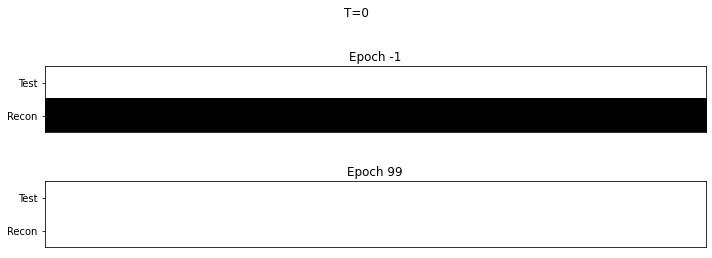

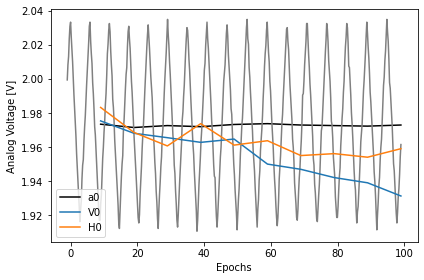

In [166]:
def generate_plots(df, tempSig=None, save=False):
    fig, ax = plt.subplots()
    ax.plot(df.epoch, df.MSE, label='T=T_train')
    try:
        ax.plot(df.epoch, df.MSE_det, label ='T=0')
    except:
        pass
    ax.legend()
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    fig.tight_layout()
    plt.show()
    
    
    
    fig, ax = plt.subplots()
    for c in df.columns:
        if c[0] == "B" or c[0] == "W":
            ax.plot(df.trainingstep, df[c], label = c)
    ax.legend()

    ax.set_xlabel("Epoch")
    ax.set_ylabel('Conductance $k_i$ [wiper val]')
    fig.tight_layout()
    plt.show()
    
    
    
    show = [np.min(df.epoch),  np.max(df.epoch)]
    norm = mpl.colors.Normalize(vmin=0, vmax=1, clip=False)
    fig, axes = plt.subplots(len(show),1, figsize=(10,2*len(show)))
    fig.suptitle("T=T_train")
    for epoch, ax in list(zip(show, fig.axes)):
        row = df[df.epoch == epoch].iloc[0]

        Vtest = np.array(row.Vtest).T
        Vrecon = np.array(row.Vrecon).T

        both = np.vstack([Vtest, Vrecon])

        ax.set_title("Epoch {}".format(epoch))
        ax.imshow(both, cmap='binary', norm=norm)
        ax.set_xticks([])
        ax.set_yticks([0,1])
        ax.set_yticklabels(['Test', 'Recon'])
    fig.tight_layout()
    plt.show()

    if 'Vtest_det' in df.columns:
        fig, axes = plt.subplots(len(show),1, figsize=(10,2*len(show)))

        fig.suptitle("T=0")

        for epoch, ax in list(zip(show, fig.axes)):
            row = df[df.epoch == epoch].iloc[0]

            Vtest = np.array(row.Vtest_det).T
            Vrecon = np.array(row.Vrecon_det).T

            both = np.vstack([Vtest, Vrecon])

            ax.set_title("Epoch {}".format(epoch))
            ax.imshow(both, cmap='binary', norm=norm)
            ax.set_xticks([])
            ax.set_yticks([0,1])
            ax.set_yticklabels(['Test', 'Recon'])
        fig.tight_layout()
        plt.show()
    
    fig, ax = plt.subplots()
    ax.plot(df.epoch,df.analogZero, color='k', label='a0')
    if tempSig:
        ax.plot(np.linspace(-1, np.max(df.epoch), len(tempSig)), tempSig, color='gray')
    for c in df.columns:
        if c[:2] == 'aV' or c[:2] == 'aH':
            ax.plot(df.epoch, df[c], label = c[1:])
    ax.legend()
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Analog Voltage [V]')
    fig.tight_layout()
    plt.show()
    
generate_plots(df, tempSig)

alpha, 1
kwvar, 30
kbvar, 5
L2, 0
L2max, 4
measureEvery, 10
temp0, 1
recordD triggered
recordR triggered
normed
ki, [5, 0, 10]
DA, [1, 1, 0]
DB, [0, 0, 0]
RA, [1, 1, 0]
RB, [0, 0, 0]
all checks passed


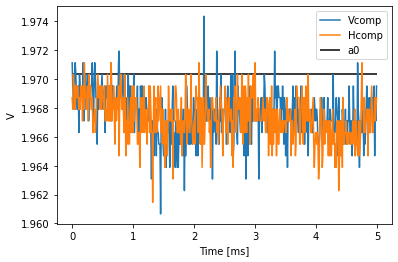

Beginning Trial 0
ki, [5, 0, 7]
DA, [1, 1, 0]
DB, [0, 0, 0]
RA, [1, 1, 0]
RB, [0, 0, 0]
Done with training


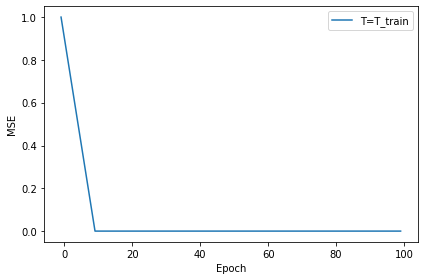

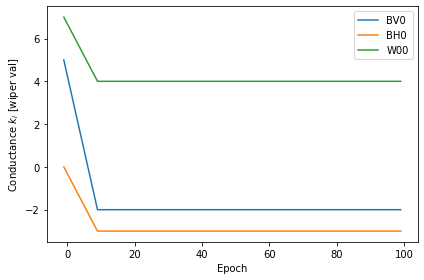

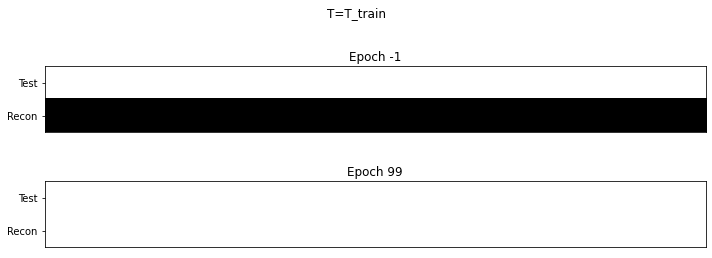

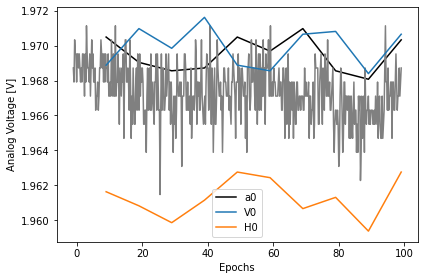

Beginning Trial 1
ki, [5, 0, -6]
DA, [1, 1, 0]
DB, [0, 0, 0]
RA, [1, 1, 0]
RB, [0, 0, 0]
Done with training


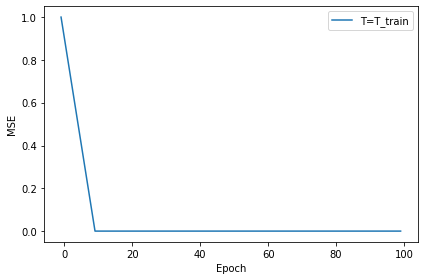

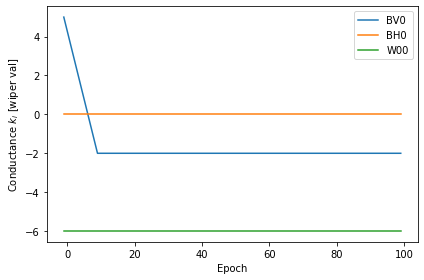

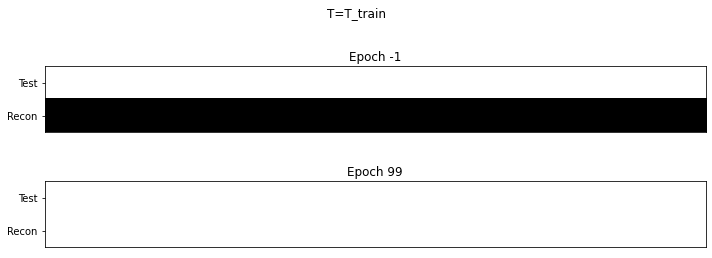

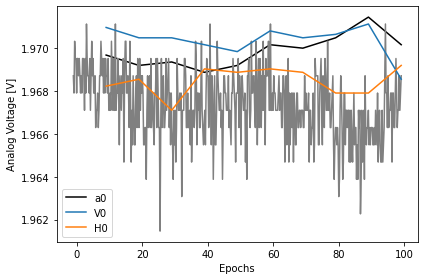

Beginning Trial 2
ki, [5, 0, 24]
DA, [1, 1, 0]
DB, [0, 0, 0]
RA, [1, 1, 0]
RB, [0, 0, 0]
Done with training


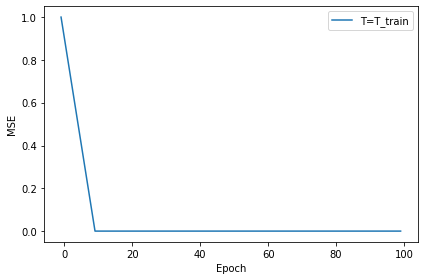

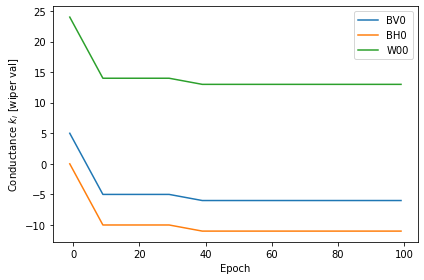

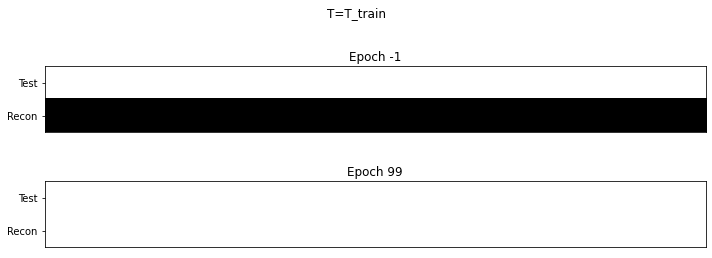

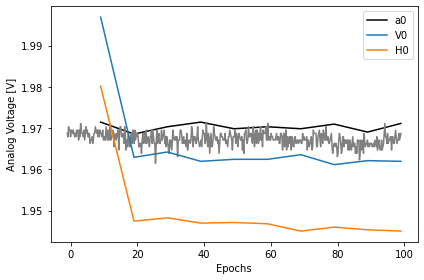

alpha, 1
kwvar, 30
kbvar, 5
L2, 0
L2max, 4
measureEvery, 10
temp0, 0
set Vtemp, 55
set Htemp, 55
detInf, 1
recordD triggered
recordR triggered
normed
ki, [5, 0, 27]
DA, [1, 1, 0]
DB, [0, 0, 0]
RA, [1, 1, 0]
RB, [0, 0, 0]
all checks passed


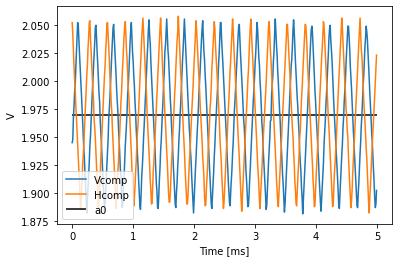

Beginning Trial 0
ki, [5, 0, 18]
DA, [1, 1, 0]
DB, [0, 0, 0]
RA, [1, 1, 0]
RB, [0, 0, 0]
Done with training


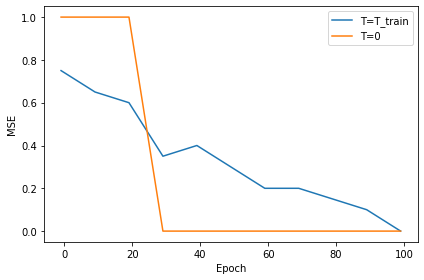

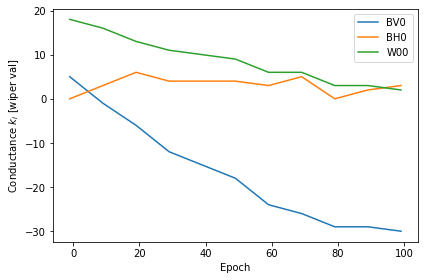

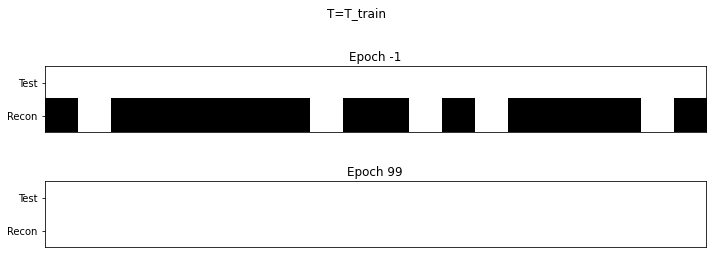

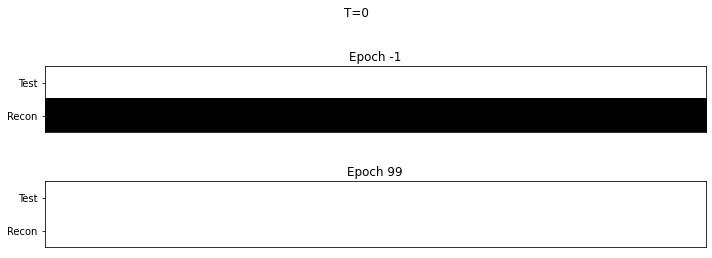

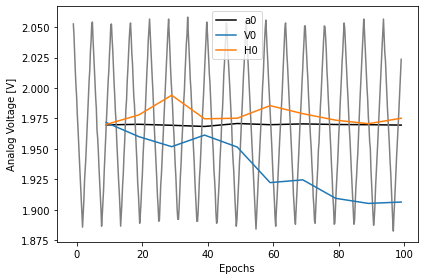

Beginning Trial 1
ki, [5, 0, -4]
DA, [1, 1, 0]
DB, [0, 1, 1]
RA, [1, 1, 0]
RB, [0, 1, 1]
Done with training


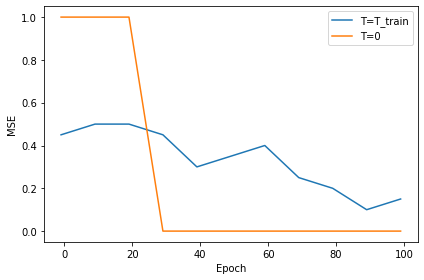

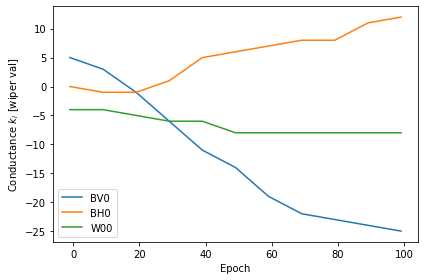

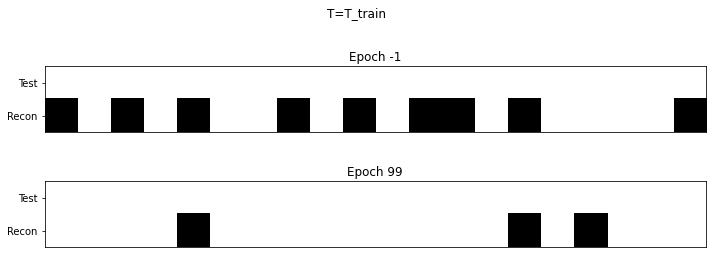

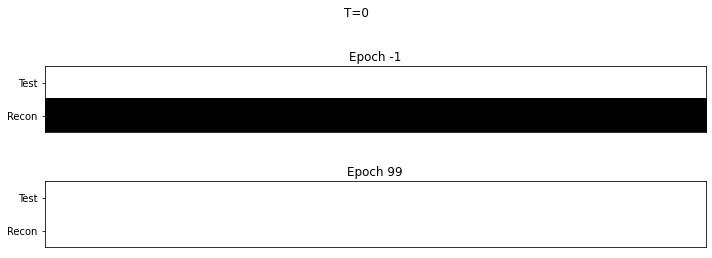

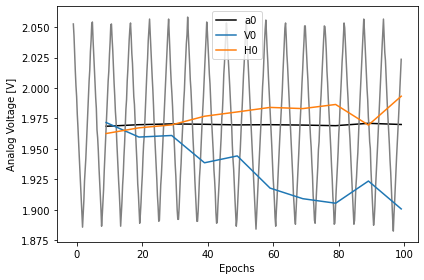

Beginning Trial 2
ki, [5, 0, -28]
DA, [1, 1, 0]
DB, [0, 0, 0]
RA, [1, 1, 0]
RB, [0, 1, 1]
Done with training


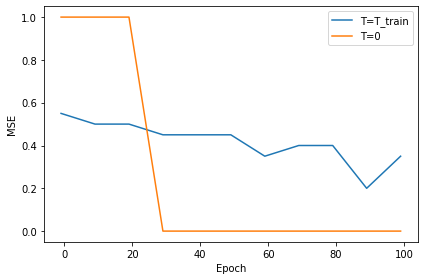

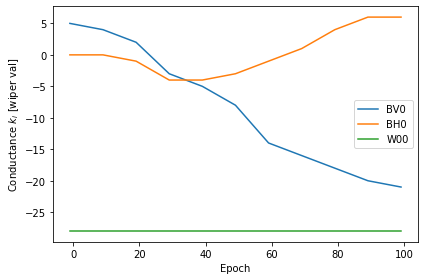

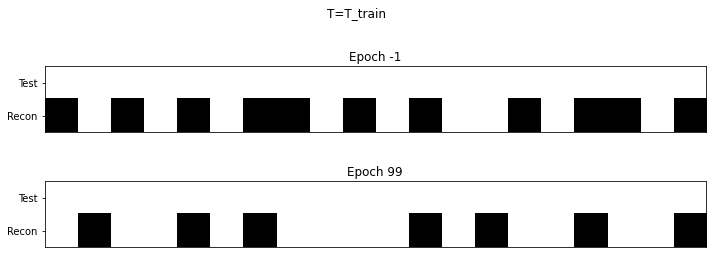

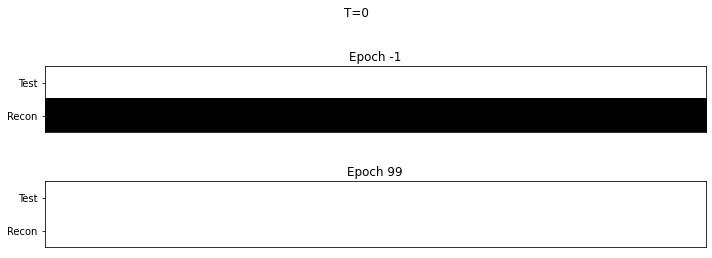

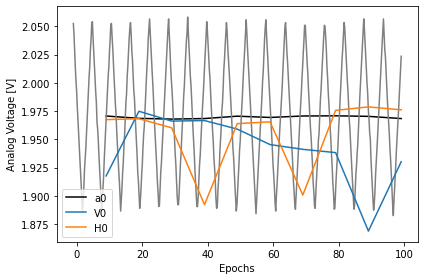

In [148]:
newhyp = hyperparams.copy()

newhyp['L2'] = 0
newhyp['includeInName'] = ['digitemp', 'L2']
newhyp['ensembleName'] = '1x1_test_zerofinite'
newhyp['epochs'] = 300
date = datetime.today().strftime('%m%d%Y')

digitemps = [-1, 0, 20, 50, 70, 90, 100, 110, 120, 128]
numTrials = 3

for digitemp in digitemps:
    newhyp['digitemp'] = digitemp
    folderpath = set_hyperparams(newhyp, date=date)
    tempSig = plot_temp()
    
    for trialn in range(numTrials):
        df = train(hyperparams, folderpath=folderpath, trialnum=trialn)
        
        generate_plots(df, tempSig)

At training temp


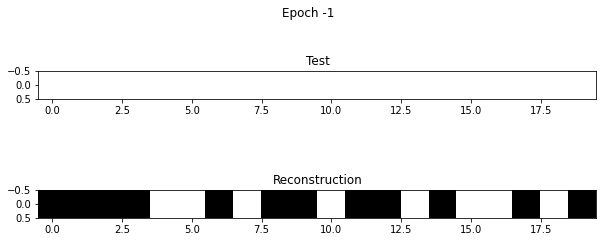

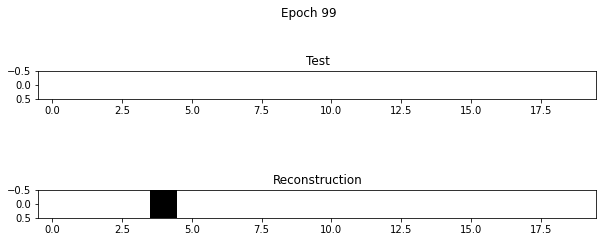

At T=0


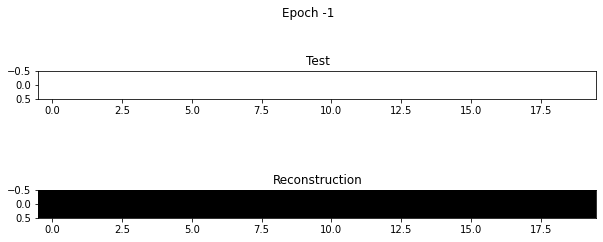

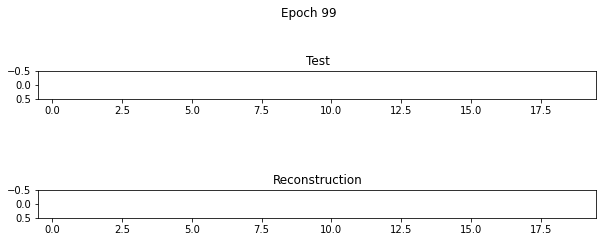

In [33]:
# show = [np.min(df.epoch),  np.max(df.epoch)]

# import matplotlib as mpl
# norm = mpl.colors.Normalize(vmin=0, vmax=1, clip=False)

# print("At training temp")
# for epoch in show:
#     row = df[df.epoch == epoch].iloc[0]
# #     print(row)

#     Vtest = np.array(row.Vtest).T
#     Vrecon = np.array(row.Vrecon).T
# #     print(Vtest)
# #     MSE = np.mean(np.linalg.norm(Vtest-Vrecon, axis=0))
# #     print(MSE)

#     fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,4))
#     fig.suptitle("Epoch {}".format(epoch))
#     ax1.imshow(Vtest, cmap='binary', norm=norm)
#     ax1.set_title('Test')
# #     plt.show()
#     ax2.imshow(Vrecon, cmap='binary', norm=norm)
#     ax2.set_title("Reconstruction")
# #     fig.savefig('figures/')
#     plt.show()
#     # Vrecons
    
# try:    
#     print("At T=0")
#     for epoch in show:
#         row = df[df.epoch == epoch].iloc[0]
#     #     print(row)

#         Vtest = np.array(row.Vtest_det).T
#         Vrecon = np.array(row.Vrecon_det).T
#     #     print(Vtest)
#     #     MSE = np.mean(np.linalg.norm(Vtest-Vrecon, axis=0))
#     #     print(MSE)

#         fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,4))
#         fig.suptitle("Epoch {}".format(epoch))
#         ax1.imshow(Vtest, cmap='binary', norm=norm)
#         ax1.set_title('Test')
#     #     plt.show()
#         ax2.imshow(Vrecon, cmap='binary', norm=norm)
#         ax2.set_title("Reconstruction")
#     #     fig.savefig('figures/')
#         plt.show()
#         # Vrecons
# except:
#     pass

In [130]:
ser.close()